In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

df = pd.read_csv('data/feature_matrix.csv')
print(f"Loaded: {df.shape[0]:,} households × {df.shape[1]} columns")

Loaded: 2,499 households × 42 columns


In [2]:
# ── Cap outlier: max_items_per_basket (your data has a 6,949 outlier) ──
cap = df['max_items_per_basket'].quantile(0.99)
df['max_items_per_basket'] = df['max_items_per_basket'].clip(upper=cap)
print(f"max_items_per_basket capped at 99th pct: {cap:.0f}")

# ── Choose features for clustering ──
# Use log-transformed versions for skewed features
# Exclude: household_key, churn label, demographics, last_purchase_day
CLUSTER_FEATURES = [
    # RFM (log-transformed)
    'recency_log',
    'frequency_log',
    'monetary_log',
    'avg_basket_log',
    'purchase_rate_log',
    # Basket behaviour
    'avg_items_per_basket_log',
    'top_store_share',
    'unique_stores_visited',
    # Promo sensitivity
    'coupon_redemption_rate_log',
    'pct_spend_on_discount',
    'was_targeted_by_campaign',
    # Category affinity
    'private_label_ratio',
    'dept_diversity',
    'unique_products',
    # Return behaviour
    'return_rate',
]

X = df[CLUSTER_FEATURES].copy()

# Standardise — KMeans is distance-based, scale matters!
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=CLUSTER_FEATURES)

print(f"\nClustering feature matrix: {X_scaled.shape}")
print(f"Features used: {CLUSTER_FEATURES}")

max_items_per_basket capped at 99th pct: 30057

Clustering feature matrix: (2499, 15)
Features used: ['recency_log', 'frequency_log', 'monetary_log', 'avg_basket_log', 'purchase_rate_log', 'avg_items_per_basket_log', 'top_store_share', 'unique_stores_visited', 'coupon_redemption_rate_log', 'pct_spend_on_discount', 'was_targeted_by_campaign', 'private_label_ratio', 'dept_diversity', 'unique_products', 'return_rate']


Testing k values...
  k=2  inertia=28,089  silhouette=0.2224
  k=3  inertia=25,395  silhouette=0.1418
  k=4  inertia=23,629  silhouette=0.1516
  k=5  inertia=22,286  silhouette=0.1360
  k=6  inertia=21,148  silhouette=0.1209
  k=7  inertia=20,141  silhouette=0.1162
  k=8  inertia=19,308  silhouette=0.1191
  k=9  inertia=18,697  silhouette=0.1118
  k=10  inertia=18,222  silhouette=0.1096


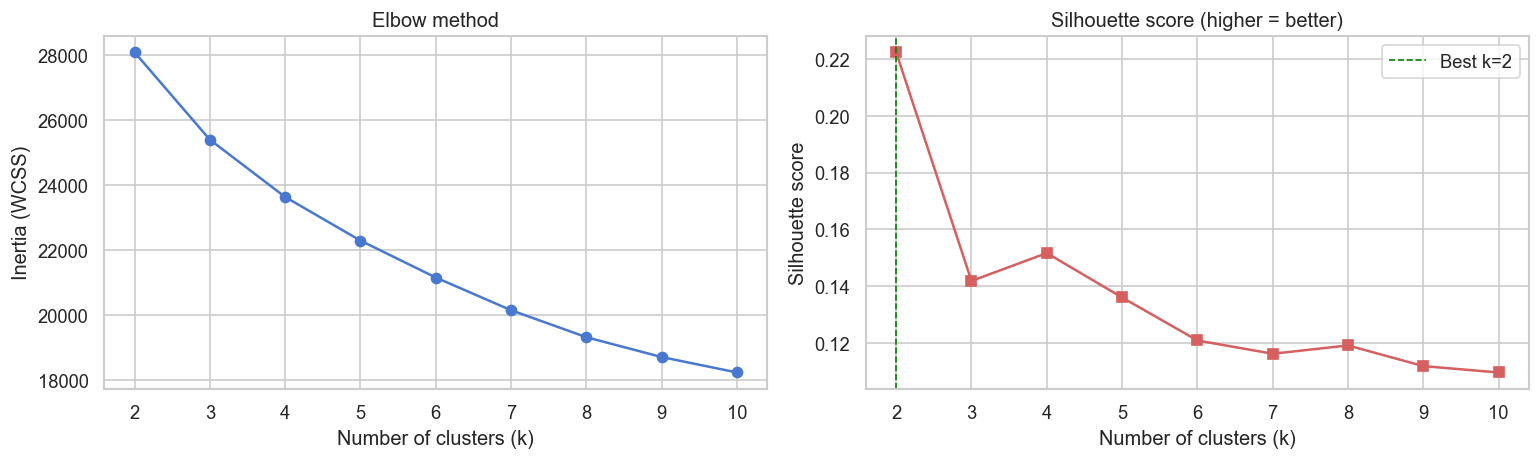


Best k by silhouette: 2 (score=0.2224)


In [3]:
K_RANGE = range(2, 11)
inertias   = []
sil_scores = []

print("Testing k values...")
for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_scaled, labels)
    sil_scores.append(sil)
    print(f"  k={k}  inertia={km.inertia_:,.0f}  silhouette={sil:.4f}")

# ── Plot elbow + silhouette side by side ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(list(K_RANGE), inertias, 'bo-', markersize=6, linewidth=1.5)
ax1.set_xlabel('Number of clusters (k)')
ax1.set_ylabel('Inertia (WCSS)')
ax1.set_title('Elbow method')
ax1.set_xticks(list(K_RANGE))

ax2.plot(list(K_RANGE), sil_scores, 'rs-', markersize=6, linewidth=1.5)
ax2.set_xlabel('Number of clusters (k)')
ax2.set_ylabel('Silhouette score')
ax2.set_title('Silhouette score (higher = better)')
ax2.set_xticks(list(K_RANGE))

best_k = list(K_RANGE)[sil_scores.index(max(sil_scores))]
ax2.axvline(best_k, color='green', linestyle='--', linewidth=1,
           label=f'Best k={best_k}')
ax2.legend()

plt.tight_layout()
plt.show()
print(f"\nBest k by silhouette: {best_k} (score={max(sil_scores):.4f})")

Final model: k=4

Cluster sizes:
cluster
0     546
1     849
2    1008
3      96
Name: count, dtype: int64


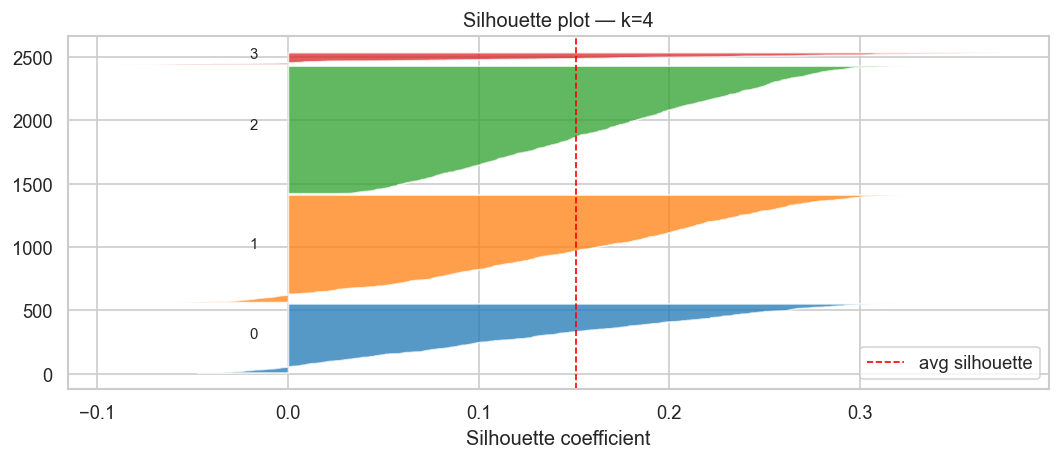

In [4]:
# ── Set K — use best_k from Cell 3, or override manually ──
# If elbow and silhouette disagree, prefer the more interpretable k
# For retail segmentation, k=4 is usually the sweet spot
K = 4  # change to e.g. K = 4 if you want to override

km_final = KMeans(n_clusters=K, random_state=42, n_init=20)
df['cluster'] = km_final.fit_predict(X_scaled)

print(f"Final model: k={K}")
print(f"\nCluster sizes:")
print(df['cluster'].value_counts().sort_index())

# Silhouette plot per cluster
sil_vals = silhouette_samples(X_scaled, df['cluster'])
fig, ax = plt.subplots(figsize=(9, 4))
y_lower = 10
colors = sns.color_palette('tab10', K)

for i in range(K):
    ith_sil = sorted(sil_vals[df['cluster'] == i])
    size_i  = len(ith_sil)
    y_upper = y_lower + size_i
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_sil,
                     facecolor=colors[i], alpha=0.75)
    ax.text(-0.02, y_lower + size_i/2, str(i), fontsize=9)
    y_lower = y_upper + 10

ax.axvline(silhouette_score(X_scaled, df['cluster']),
           color='red', linestyle='--', linewidth=1, label='avg silhouette')
ax.set_xlabel('Silhouette coefficient')
ax.set_title(f'Silhouette plot — k={K}')
ax.legend()
plt.tight_layout()
plt.show()

PCA variance explained: PC1=37.0%  PC2=12.0%  Total=49.0%


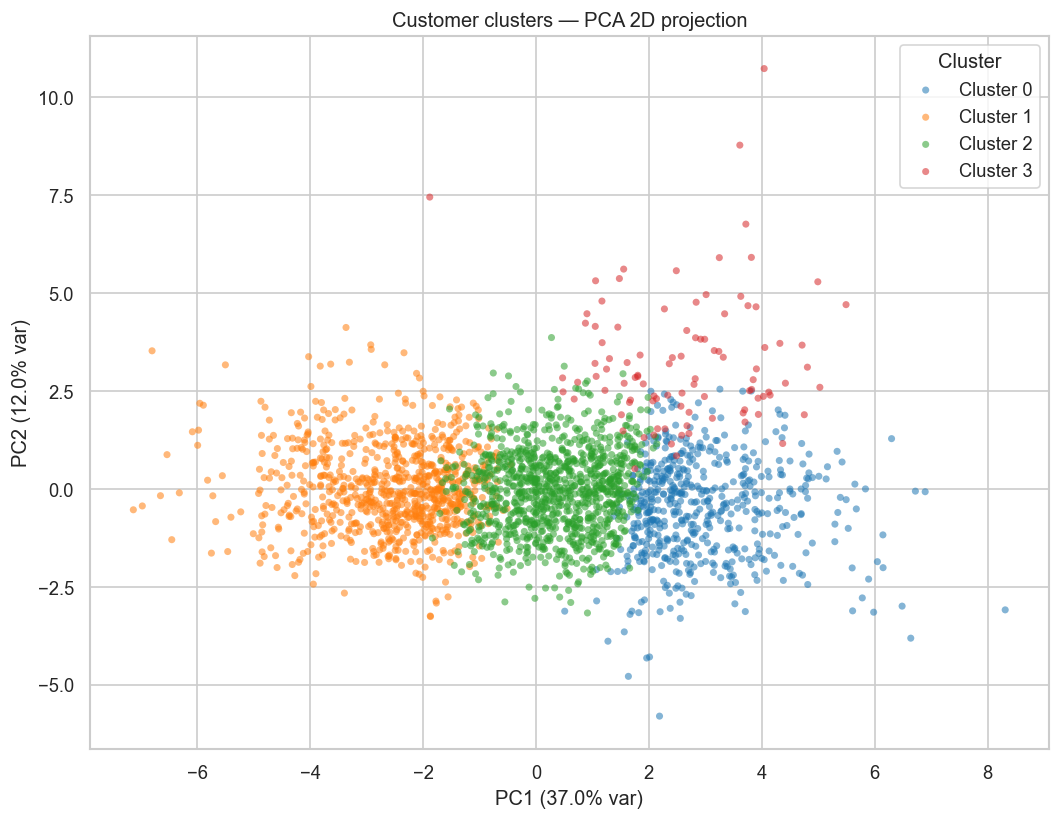

In [5]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"PCA variance explained: PC1={pca.explained_variance_ratio_[0]*100:.1f}%  "
      f"PC2={pca.explained_variance_ratio_[1]*100:.1f}%  "
      f"Total={sum(pca.explained_variance_ratio_)*100:.1f}%")

fig, ax = plt.subplots(figsize=(9, 7))
colors = sns.color_palette('tab10', K)

for i in range(K):
    mask = df['cluster'] == i
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=[colors[i]], label=f'Cluster {i}',
               alpha=0.55, s=18, edgecolors='none')

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
ax.set_title('Customer clusters — PCA 2D projection')
ax.legend(title='Cluster')
plt.tight_layout()
plt.show()

Cluster profile (median values):

cluster                        0        1         2         3
recency                    1.000   18.000     5.000     2.000
frequency                182.000   25.000    77.000    94.500
monetary                5464.075  523.870  2049.540  5046.890
avg_basket                30.178   22.204    27.778    51.833
purchase_rate              0.324    0.046     0.138     0.177
top_store_share            0.682    0.714     0.793     0.775
coupon_redemption_rate     0.000    0.000     0.000     0.093
pct_spend_on_discount      0.139    0.151     0.153     0.157
private_label_ratio        0.285    0.275     0.289     0.245
dept_diversity            16.000    9.000    12.000    15.000
unique_products          908.000  138.000   440.500   848.500
return_rate                0.053    0.034     0.045     0.158
churned                    0.000    0.000     0.000     0.000
size                     546.000  849.000  1008.000    96.000
churn_pct                  1.100   1

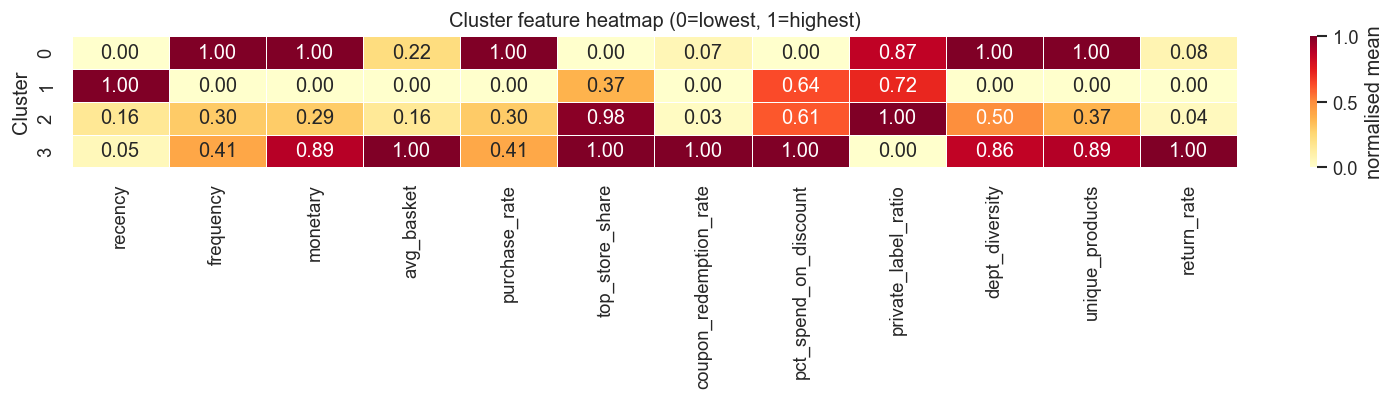

In [6]:
PROFILE_COLS = [
    'recency', 'frequency', 'monetary', 'avg_basket',
    'purchase_rate', 'top_store_share',
    'coupon_redemption_rate', 'pct_spend_on_discount',
    'private_label_ratio', 'dept_diversity',
    'unique_products', 'return_rate', 'churned'
]

profile = df.groupby('cluster')[PROFILE_COLS].median().round(3)
profile['size']      = df.groupby('cluster').size()
profile['churn_pct'] = (df.groupby('cluster')['churned'].mean() * 100).round(1)

print("Cluster profile (median values):\n")
print(profile.T.to_string())

# Heatmap of normalised cluster means for quick visual comparison
profile_means = df.groupby('cluster')[PROFILE_COLS[:-1]].mean()
profile_norm  = (profile_means - profile_means.min()) / (profile_means.max() - profile_means.min())

fig, ax = plt.subplots(figsize=(13, 3.5))
sns.heatmap(profile_norm, annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.4, ax=ax, cbar_kws={'label': 'normalised mean'})
ax.set_title('Cluster feature heatmap (0=lowest, 1=highest)')
ax.set_ylabel('Cluster')
plt.tight_layout()
plt.show()

In [7]:
# ── Automatically name clusters based on RFM profile ──
# Logic: rank clusters by monetary median, then refine by recency & churn

cluster_stats = df.groupby('cluster').agg(
    med_monetary  = ('monetary',  'median'),
    med_recency   = ('recency',   'median'),
    med_frequency = ('frequency', 'median'),
    churn_rate    = ('churned',   'mean'),
    med_discount  = ('pct_spend_on_discount', 'median')
)

print("Cluster stats for naming:\n")
print(cluster_stats.round(3).to_string())

# ── MANUAL STEP: Read the output above and assign names ──
# After running this cell, look at the stats and fill in the dict below.
# Example naming logic:
#   High monetary + low recency  → "Premium Loyalists"
#   High discount + low monetary → "Deal Hunters"
#   Low frequency + high recency → "Churn Risk"
#   Mid everything               → "Occasional Shoppers"
#
# FILL THIS IN after reading the output:
SEGMENT_NAMES = {
    0: 'Premium Loyalists',       # was Segment A — recency=1, freq=182, spend=$5,464
    1: 'Churn Risk',              # was Segment B — recency=18, freq=25, spend=$524, churn=15.7%
    2: 'Occasional Shoppers',     # was Segment C — recency=5, freq=77, spend=$2,050
    3: 'High-Value Deal Seekers', # was Segment D — avg_basket=$51, return_rate=15.8%
}

df['segment_name'] = df['cluster'].map(SEGMENT_NAMES)
print(f"\nSegment distribution:")
print(df['segment_name'].value_counts())

Cluster stats for naming:

         med_monetary  med_recency  med_frequency  churn_rate  med_discount
cluster                                                                    
0            5464.075          1.0          182.0       0.011         0.139
1             523.870         18.0           25.0       0.157         0.151
2            2049.540          5.0           77.0       0.031         0.153
3            5046.890          2.0           94.5       0.010         0.157

Segment distribution:
segment_name
Occasional Shoppers        1008
Churn Risk                  849
Premium Loyalists           546
High-Value Deal Seekers      96
Name: count, dtype: int64


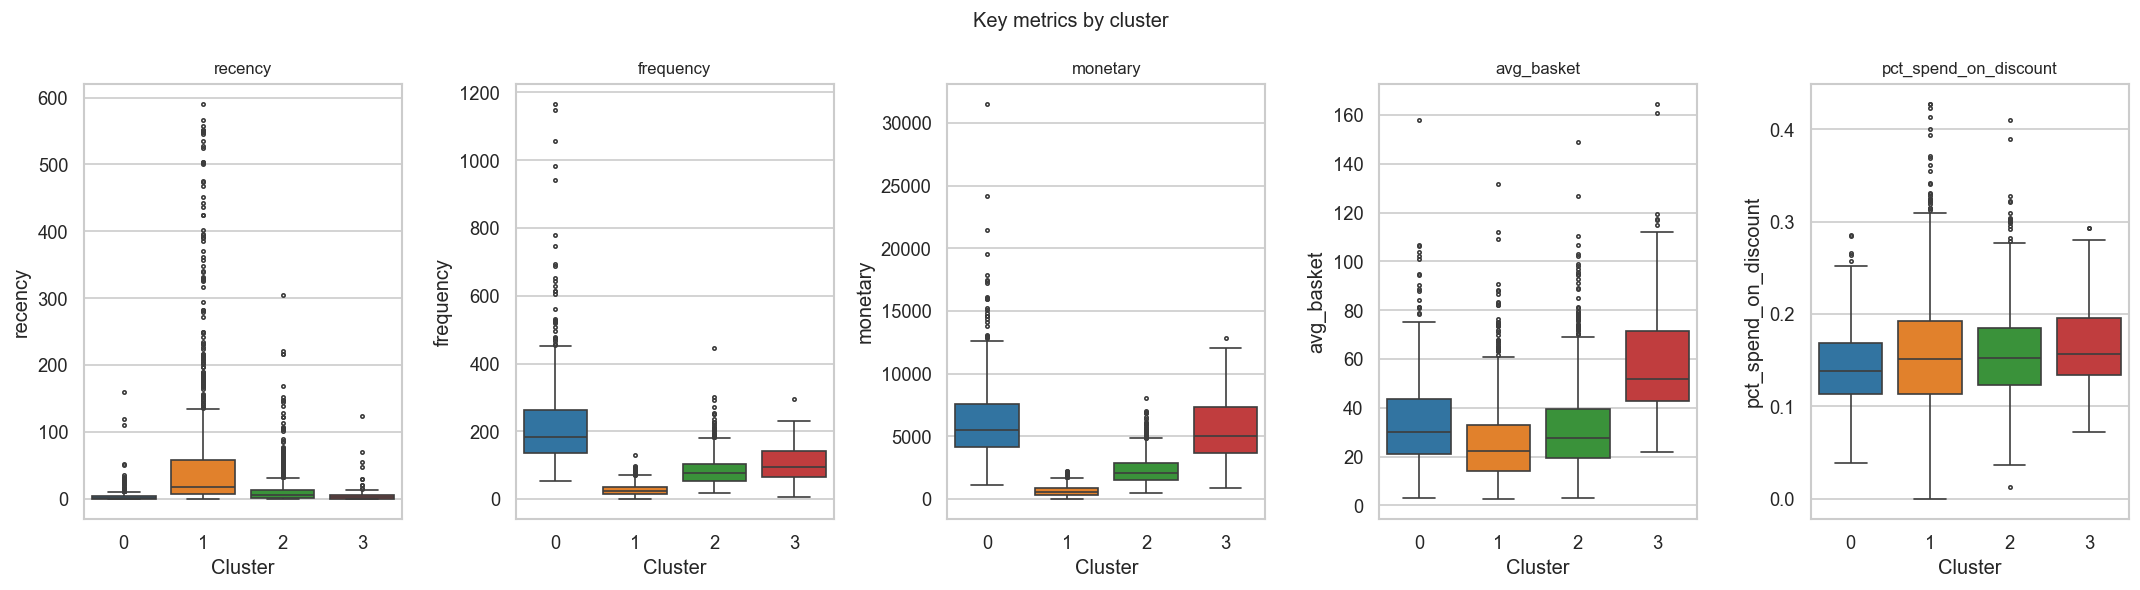

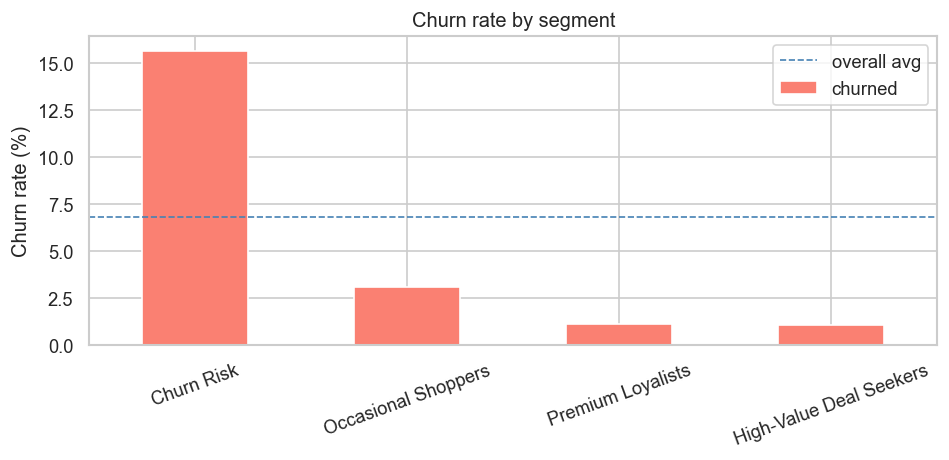

In [8]:
# ── RFM boxplots per segment ──
rfm_cols = ['recency', 'frequency', 'monetary', 'avg_basket', 'pct_spend_on_discount']

fig, axes = plt.subplots(1, 5, figsize=(18, 5))
palette = sns.color_palette('tab10', K)

for i, col in enumerate(rfm_cols):
    sns.boxplot(data=df, x='cluster', y=col, ax=axes[i],
                palette=palette, flierprops={'markersize': 2})
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('Cluster')

fig.suptitle('Key metrics by cluster', fontsize=12)
plt.tight_layout()
plt.show()

# ── Churn rate bar by segment ──
churn_by_seg = df.groupby('segment_name')['churned'].mean().sort_values(ascending=False) * 100

fig, ax = plt.subplots(figsize=(8, 4))
churn_by_seg.plot(kind='bar', ax=ax, color='salmon', edgecolor='white')
ax.axhline(df['churned'].mean()*100, color='steelblue',
           linestyle='--', linewidth=1, label='overall avg')
ax.set_ylabel('Churn rate (%)')
ax.set_title('Churn rate by segment')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=20)
ax.legend()
plt.tight_layout()
plt.show()

In [9]:
out_path = 'data/feature_matrix_segmented.csv'
df.to_csv(out_path, index=False)
print(f"✓ Saved → {out_path}")
print(f"  Shape    : {df.shape}")
print(f"  Segments : {df['segment_name'].unique().tolist()}")
print(f"\nChurn rate per segment:")
print((df.groupby('segment_name')['churned'].mean()*100).round(1).to_string())
print("\n✓ Phase 3 complete. Ready for Phase 4 (Churn Prediction).")

✓ Saved → data/feature_matrix_segmented.csv
  Shape    : (2499, 44)
  Segments : ['High-Value Deal Seekers', 'Occasional Shoppers', 'Churn Risk', 'Premium Loyalists']

Churn rate per segment:
segment_name
Churn Risk                 15.7
High-Value Deal Seekers     1.0
Occasional Shoppers         3.1
Premium Loyalists           1.1

✓ Phase 3 complete. Ready for Phase 4 (Churn Prediction).
